Classificazione SVM

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
data=load_breast_cancer()
X=data.data
y=data.target
display(pd.DataFrame(X, columns=data.feature_names).head())
display(pd.DataFrame(y, columns=["target"]))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [7]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

Alleniamo il primo modello con un kernel lineare

In [11]:
svc_linear=SVC(kernel="linear",C=1.0,random_state=42)
svc_linear.fit(X_scaled,y)
y_pred_linear=svc_linear.predict(X_scaled)
mse_linear=mean_squared_error(y,y_pred_linear)
r2_linear=r2_score(y,y_pred_linear)

In [13]:
svc_rbf=SVC(kernel="rbf",C=1.0,random_state=42)
svc_rbf.fit(X_scaled,y)
y_pred=svc_rbf.predict(X_scaled)
mse_rbf=mean_squared_error(y,y_pred)
r2_rbf=r2_score(y,y_pred)

In [14]:
print(f"LINEAR \nMSE: {mse_linear}\t R2:{r2_linear}")
print(f"RBF \nMSE: {mse_rbf}\t R2:{r2_rbf}")

LINEAR 
MSE: 0.012302284710017574	 R2:0.9473732889382168
RBF 
MSE: 0.012302284710017574	 R2:0.9473732889382168


facciamo il plot

selezioniamo 2 feature per rappresentarle su un piano 2D

In [15]:
feature_0=0
feature_1=1
X_2d=X_scaled[:,[feature_0,feature_1]]

riaddetro i modelli su questo dataset ridotto

In [16]:
svc_linear_plot=SVC(kernel="linear",C=1.0,random_state=42)
svc_linear_plot.fit(X_2d,y)
svc_rbf_plot=SVC(kernel="rbf",C=1.0,random_state=42)
svc_rbf_plot.fit(X_2d,y)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


creo una griglia

In [17]:
X_min, X_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
Y_min, Y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(X_min, X_max, 0.02), np.arange(Y_min, Y_max, 0.01))


predizione su questi dati

In [19]:
Z_linear = svc_linear_plot.predict(np.c_[xx.ravel(), yy.ravel()])
Z_linear = Z_linear.reshape(xx.shape)
Z_rbf = svc_rbf_plot.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

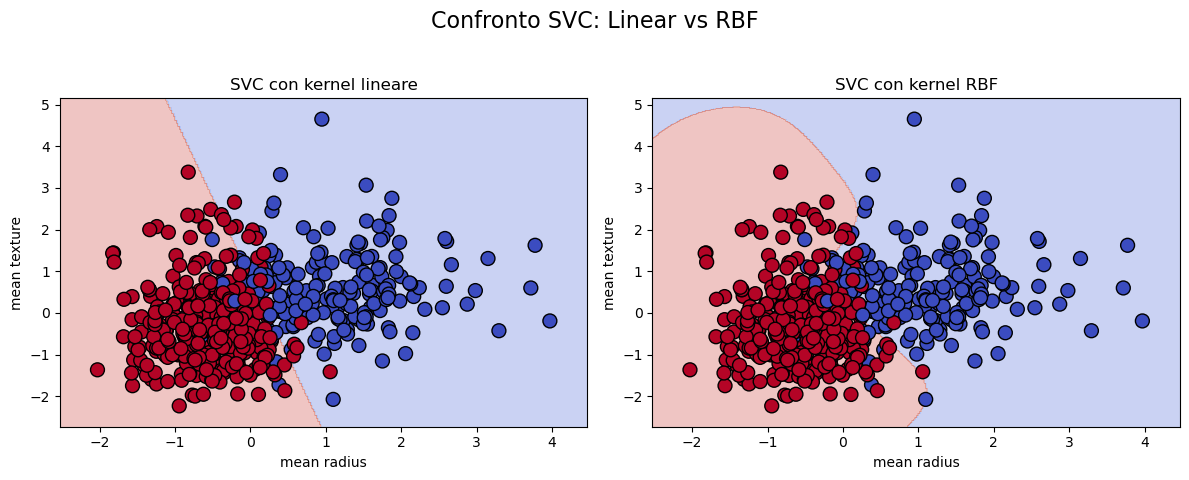

In [22]:
plt.figure(figsize=(12, 5))
plt.suptitle("Confronto SVC: Linear vs RBF", fontsize=16)

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_linear, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors='k', marker='o', s=100, cmap=plt.cm.coolwarm)
plt.title("SVC con kernel lineare") 
plt.xlabel(data.feature_names[feature_0])
plt.ylabel(data.feature_names[feature_1])
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_rbf, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors='k', marker='o', s=100, cmap=plt.cm.coolwarm)
plt.title("SVC con kernel RBF")
plt.xlabel(data.feature_names[feature_0])
plt.ylabel(data.feature_names[feature_1])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [24]:
tot_sampples=len(y)
correct_linear=np.sum(y_pred_linear==y)
accuracy_linear=correct_linear/tot_sampples
correct_rbf=np.sum(y_pred==y)
accuracy_rbf=correct_rbf/tot_sampples
print(f"Totale campioni: {tot_sampples}")
print(f"Campioni correttamente classificati SVC Lineare: {correct_linear}")
print(f"Campioni correttamente classificati SVC RBF: {correct_rbf}")
print(f"Accuratezza SVC Lineare: {accuracy_linear:.2f}")
print(f"Accuratezza SVC RBF: {accuracy_rbf:.2f}")

Totale campioni: 569
Campioni correttamente classificati SVC Lineare: 562
Campioni correttamente classificati SVC RBF: 562
Accuratezza SVC Lineare: 0.99
Accuratezza SVC RBF: 0.99


Entrambi i modelli hanno una buona accuratezza. Il metodo linerare già ottine buon fitting e non c'è necessità di utilizzare un kernel più sofisticato